In [3]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import rc_context
from scipy.stats import gaussian_kde
import mplfinance as mpf # k线图
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体显示
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Heiti TC', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

### 创建你的第一个量化策略
1. 参数设置：ticker 数据获取与标准化
2. 参数设置：captical, commission, benchmark
3. 策略与运行：indicators, signals
4. 策略与运行：cross-order, limit, pos, 涨跌停
5. 统计与验证：daily pnl, totaly values, 日盈亏逐笔核对
6. 统计与验证：strategy statistics、策略报告
7. 结果可视化：净值、回撤、盈亏分布、基准对比
8. 实操：打造可复用的量化策略模板

In [4]:
# 全局参数设置（或数据模块）：工商银行为例
ticker = "518880.SS" # 黄金ETF：GLD，华夏黄金ETF：518880.SS
benchmark_ticker = "000300.SS" # 上证：000001.SS，沪深300：000300.SS，中证500：000905.SS
start_date = "2023-01-01"
end_date = "2025-10-30"

# 策略模块：全局参数
boll_period = 5
boll_k = 1.5

#### 参数设置：ticker 数据获取与标准化
- 数据获取：yf.download(), 定义参数（股票代码、开始日期、结束日期、复权方式）
- 数据清洗：nan值 -> dropna
- 数据预览：整体看下数据

In [5]:
# 函数1：数据获取
def fetcher_data(ticker:str,start_date:str,end_date:str,auto_clean=True) -> pd.DataFrame:
    """ 获取数据 """
    try:
        print("正在获取历史数据：",ticker, start_date, end_date)
        data = yf.download(tickers=ticker,start=start_date,end=end_date,progress=False)
        # yfinance 个性化处理：去除第二行的列名，即ticker值
        data = data.droplevel(level=1,axis=1)
        print("完成数据获取，共有记录（条数）：", len(data))

        if auto_clean:
            clean_data(data)
    
        return data
    except Exception as e:
        print("获取数据异常：",e)
        return pd.DataFrame

# 函数2：数据清洗
def clean_data(data:pd.DataFrame) -> pd.DataFrame:
    """ 清洗数据：缺失值 """
    try:
        count_nan = data.isnull().sum().sum()
        print("当前data共有缺失值（个数）：",count_nan)
        data = data.dropna()
        count_nan = data.isnull().sum().sum()
        print("缺失值处理完毕，当前缺失值（个数）：",count_nan)
        return data
    except Exception as e:
        print("获取数据异常：",e)
        return data

# 函数3：数据预览
def preview_data(data:pd.DataFrame) -> pd.DataFrame:
    """ 按需要的格式预览数据 """
    print("数据预览：",data)

#### 参数设置：capital, commission, slippage, benchmark
- initial_capital：初始资金，决定能买多少股票，是收益率、仓位计算的基准，回测设置为尽可能大的整数（如100万）
- commission: 交易手续费（佣金 + 税费），总共约为千1，即0.1% -> 0.001
- slippage: 滑点（成交价偏差），实际成交价与理论信号价的偏差，反应市场流动性和成交延迟，回测过程中设置为万5，即0.05% -> 0.0005
- benchmark: 市场基准（beta），使用上证指数 000001.SS

In [6]:
# 全局交易参数设置
trading_config = {
    "initial_capital":1000000,
    "commission":0.001, # a股买入的话是在0.0003，卖出的话 0.0007，通用使用0.001
    "slippage":0.0005
}

In [7]:
# 函数4：对比投资标的与市场基准的价格曲线
def plot_compare_benchmark(ticker,benchmark_ticker,data,benchmark_data,auto_normalize=True):
    """绘制两个资产的收盘价或相对涨幅对比图，自动兼容不同时间索引与缺失值"""
    # 合并数据（按日期索引外连接，允许不同长度）
    combined_data = pd.concat(
        [data['Close'], benchmark_data['Close']],
        axis=1,
        join='outer'  # outer 合并所有日期（不同日期都保留）
    )
    combined_data.columns = [ticker, benchmark_ticker]

    # 填充缺失数据（可选：前向填充）
    combined_data = combined_data.ffill().bfill()

    # 数据标准化（0~1）：解决价格差异太大导致无法直观对比的问题
    if auto_normalize:
        combined_data = combined_data / combined_data.iloc[0] * 100
        ylable = "相对涨幅（%）"
    else:
        ylable = "收盘价"

    combined_data.plot(figsize=(12,5), linewidth=2)
    plt.title(f"{ticker} vs {benchmark_ticker} 收盘价对比")
    plt.xlabel("日期")
    plt.ylabel(ylable)
    plt.grid(alpha=0.3)

#### 策略与运行：indicators, signals
- 核心作用: 找到特征/因子 => 建立特征模型（单个因子/多个因子/权重配置）=> 创建策略规则 => 生成交易信号（涉及配对交易的问题）=> 进行后续回测
- 因子概念: 基于此进行量化策略的规则编写，比如：技术指标（KDJ-动量因子、MA-趋势因子）、基本面指标（PE-价值因子）
- 代码实现: 单因子（BOLL）=> 价格上穿下轨：买入/做多，价格下穿上轨：卖出/平仓/做空
- 函数创建: def calculate_boll（因子指标模块）、def generate_signals（因子指标/策略模块）、def plot_signals（可视化信号-验证计算）

In [8]:
# 函数4：def calculate_boll（因子指标模块）
def calculate_boll(data:pd.DataFrame,period:int,std_k:int) -> pd.DataFrame:
    """ 计算Boll布林带指标
        - 中轨：n日移动均线
        - 上轨：n日移动均线 + k * n日收盘价std
        - 下轨：n日移动均线 - k * n日收盘价std
    """
    try:
        data['BOLL_MA'] = data['Close'].rolling(window=period).mean()
        data['BOLL_STD'] = data['Close'].rolling(window=period).std()
        data['BOLL_UP'] = data['BOLL_MA'] + std_k * data['BOLL_STD']
        data['BOLL_DN'] = data['BOLL_MA'] - std_k * data['BOLL_STD']
        print(f"已完成指标计算：BOLL, 周期-{period}, 标准差倍数-{std_k}")
        return data
    except Exception as e:
        print("BOLL计算异常：",e)
        return pd.DataFrame

# 函数5：def generate_signals（因子指标/策略模块）
def generate_signals(data:pd.DataFrame,save_csv=False) -> pd.DataFrame:
    """ 通用模块：参数化设置实现多因子信号的生成，也是核心需要修改的策略规则逻辑 """
    try:
        data['Signal'] = 0
        
        # 以下内容为信号生成逻辑，可以自定义，核心是获取 Signal 列的值（1买入 -1卖出）
        
        # 单因子（BOLL）=> 价格上穿下轨：买入/做多，价格下穿上轨：卖出/平仓/做空
        prev_price = data['Close'].shift(1)
        buy_condition = (prev_price<=data['BOLL_DN']) & (data['Close']>=data['BOLL_DN'])
        sell_condition = (prev_price>=data['BOLL_UP']) & (data['Close']<=data['BOLL_UP'])

        data.loc[buy_condition,'Signal'] = 1
        data.loc[sell_condition,'Signal'] = -1
        print(f"已完成信号生成：BOLL，买入信号次数：{buy_condition.sum()}，卖出信号次数：{sell_condition.sum()}")

        if save_csv:
            filename = f"{ticker}_signals_{start_date}_{end_date}.csv"
            data.to_csv(filename, encoding='utf-8-sig')
            print(f"✅ 数据已保存到：{filename}")
            
        return data
    except Exception as e:
        print("信号生成异常：",e)
        return pd.DataFrame
        

# 函数6：def plot_signals（可视化信号-验证计算）
def plot_signals_boll(signals_data:pd.DataFrame, save_fig=False):
    """ 绘制指标与信号 """
    
    # 定义子图：布林带上中下轨、买入卖出信号
    data = signals_data.copy()
    buy_signal = np.where(data['Signal']==1,data['Close'],np.nan)
    sell_signal = np.where(data['Signal']==-1,data['Close'],np.nan)
    
    subplots = [
        mpf.make_addplot(data['BOLL_MA'],color='blue',linestyle='--',label='Middle'),
        mpf.make_addplot(data['BOLL_UP'],color='red',linestyle='--',label='Upper'),
        mpf.make_addplot(data['BOLL_DN'],color='green',linestyle='--',label='Lower'),
        mpf.make_addplot(buy_signal, type='scatter', marker='^', markersize=100, color='red',label='Buy'),
        mpf.make_addplot(sell_signal, type='scatter', marker='v', markersize=100, color='green',label='Sell')
    ]

    s = mpf.make_mpf_style(
        base_mpf_style='yahoo',
        rc={
            'font.sans-serif': ['Microsoft YaHei', 'SimHei', 'Heiti TC', 'Arial Unicode MS', 'DejaVu Sans'],
            'axes.unicode_minus': False
        })
    
    # ⚡关键：使用 returnfig=True 获取 figure 对象
    fig, axlist = mpf.plot(
        data,
        type='candle',
        style=s,
        title='布林带交易信号可视化',
        addplot=subplots,
        volume=False,
        figsize=(12, 6),
        tight_layout=True,
        xrotation=15,
        returnfig=True  # ✅ 让 mplfinance 返回 fig
    )

    # ✅ 保存图像
    if save_fig:
        filename = f"{ticker}_backtest_signals_chart.png"
        fig.savefig(filename, dpi=300, bbox_inches="tight")
        print(f"✅ 图片已保存到: {filename}")

    plt.close(fig)  # 释放资源，防止Jupyter重复输出

#### 策略与运行：cross-order, limit, pos, 涨跌停
- 核心功能：执行买卖交易、存储交易记录、每笔交易（卖出）的盈亏分析（净利润，收益率）
- cross-order 撮合订单：买入价格 >= 卖出价格（卖盘）就会自动撮合，否则就会挂单表示委托状态中
- 委托单类型：market 市价单 => 滑点、limit 限价单 => 无法交易 => limit price ± 0.001%
- 处理涨跌停：前收盘价 > ± 10% 则无法成交
- 函数：def execute_trade => 下订单+存交易记录

In [9]:
# 设置交易信息初始值（全局） => 思考个人账户页面的汇总数据有哪些
trading_state = {
    'cash': trading_config['initial_capital'], # 账户可用资金
    'positions': {}, # 存储投资标的持仓，如：{"000001.SS":10000, "601398.SS":2000}
    'trades': [], # 存放交易记录：price,quantity,date,cost,net_revenue,profit_rate
    'values': [] # 存放每日盈亏数据：position * price -> pos value (+cash)-> total value->今明总值比较->日盈亏
}

In [10]:
# 函数7：def execute_trade => 下订单+存交易记录
def execute_trade(symbol:str, quantity: int, price: float, date: pd.Timestamp, commission: float = trading_config['commission']):
    """
    执行交易：买入、卖出、交易记录；实际的交易接口交互的过程中，交易信息是直接发给券商API => 进行订单委托、更新账户信息 => 得到状态码
    """
    try:
        # 买入
        if quantity > 0:
            # 买入：执行交易 => 是否满足可交易条件：可用资金足够 => 更新持仓信息
            cost = quantity * price * (1+commission)
            if cost <= trading_state['cash']:
                trading_state['cash'] -= cost # 资金流出
                trading_state['positions'][symbol] = trading_state['positions'].get(symbol,0) + quantity # 流入
                # 买入：记录交易 => 汇总信息并添加至 trading_state['trades'] => cost 总成本
                trade_record = {
                    'symbol':symbol,
                    'quantity':quantity,
                    'price':price,
                    'type':'buy',
                    'timestamp':date,
                    'cost':cost,
                    'commission':cost - (quantity * price)
                }
                trading_state['trades'].append(trade_record)

                print(f"➕买入成功！{symbol} +{quantity}股 @{price} 总成本 {cost} 可用资金 {trading_state['cash']}")
            else:
                print(f"❌可用资金不足！总成本 {cost} 可用资金 {trading_state['cash']}")
                
        # 卖出
        else:
            quantity = abs(quantity)
            # 卖出：执行交易 => 是否满足可交易条件：仓位pos足够 => 计算收益 => 更新持仓信息
            if trading_state['positions'].get(symbol,0) >= quantity:
                # 计算净收益
                gross_revenue = quantity * price # 按当前价格和仓位卖出的市值
                commission_cost = gross_revenue * commission # 计算佣金
                net_revenue = gross_revenue - commission_cost # 纯收益

                # 找到买入成本
                buy_cost = get_latest_buy_cost(symbol)
                
                # 计算盈亏 profit and loss 盈亏
                profit_loss = net_revenue - buy_cost # 当前卖出和此前买入的收益/亏损值（差值）
                profit_rate = profit_loss / buy_cost # >0 正收益 <0 负收益
                profit_rate_pct = f"{profit_rate:.2%}"

                # 更新持仓和可用资金
                trading_state['positions'][symbol] -= quantity # 减持，资金流出
                trading_state['cash'] += net_revenue
                
                # 卖出：记录交易 => 汇总信息并添加至 trading_state['trades'] => 净收益 net_revenue, 收益比
                trade_record = {
                    'symbol':symbol,
                    'quantity':quantity,
                    'price':price,
                    'type':'sell',
                    'timestamp':date,
                    'gross_revenue':gross_revenue,
                    'commission':commission_cost,
                    'net_revenue':net_revenue,
                    'buy_cost':buy_cost,
                    'profit_loss':profit_loss,
                    'profit_rate':profit_rate,
                    'profit_rate_pct':profit_rate_pct
                }
                
                trading_state['trades'].append(trade_record)
                print(f"➖卖出成功！{symbol} -{quantity}股 @{price} 净收益 {net_revenue} 盈亏 {profit_loss} 盈亏比 {profit_rate_pct} 可用资金 {trading_state['cash']}")          
            else:
                print(f"❌可用仓位不足！总仓位 {trading_state['positions'].get(symbol,0)}")
                          
    except Exception as e:
        print(f"⚠️交易异常：{e}")

# 函数8：辅助计算函数，找到最近买入记录对应的总成本
def get_latest_buy_cost(symbol:str) -> float:
    """
    获取指定投资标的的最新买入成本（全进全出策略，即：无加减仓逻辑）
    """
    for trade in reversed(trading_state['trades']):
        if trade['symbol'] == symbol and trade['type'] == 'buy':
            return trade['cost'] 
    print(f"⚠️警告：未找到 {symbol} 的买入记录")
    return 0.0

#### 统计与验证：daily profit and loss, position value, total value, 日盈亏数据逐笔核对
- 每日盈亏：当日的总市值 - 昨日的总市值 => 反应你持仓标的的整体涨跌幅情况
- 账户总市值：总市值 = 持仓市值（获取当前投资标的的股数/份额） + 账户可用资金
- 核心功能和函数：根据交易信号执行交易（进行回测+执行策略）=> def run_strategy 

In [11]:
# 函数9：def run_strategy
def run_strategy(symbol:str, signals:pd.DataFrame, save_csv=False) -> pd.DataFrame:
    """
    根据交易信号执行交易，并将计算的市值和盈亏数据进行存储
    """
    try:
        # 验证是否有 signal 列
        if 'Signal' not in signals.columns:
            raise ValueError("Data中必须包含 Signal 列")
    
        # 按行遍历数据 => 获取 date, price, signal => 并后续计算quantity
        for i, (date,row) in enumerate(signals.iterrows()):
            signal = row['Signal']
            price = row['Close']
            
            # 买入 - 计算按可用资金最多可以买入的股数（全仓进出 + 佣金），如果非全仓 - 可用资金的10%
            if signal == 1:
                max_quantity = int(trading_state['cash'] / ( price * (1 + trading_config['commission'])))
                if max_quantity > 0:
                    execute_trade(symbol, max_quantity, price, date)
            # 卖出
            elif signal == -1:
                current_quantity = trading_state['positions'].get(symbol,0)
                if current_quantity > 0:
                    execute_trade(symbol, -current_quantity, price, date)
    
            # 计算市值：持仓、账户总值
            position_value = trading_state['positions'].get(symbol,0) * price
            total_value = position_value + trading_state['cash']
    
            # 计算盈亏：当日 - 昨日总值
            if i == 0:
                daily_pnl = 0
            else:
                previous_value = trading_state['values'][-1]['total_value']
                daily_pnl = total_value - previous_value # 昨日市值
    
            # 存储数据
            daily_record = {
                'date':date,
                'signal':signal,
                'price':price,
                'cash':trading_state['cash'],
                'position':trading_state['positions'].get(symbol,0),
                'position_value':position_value,
                'total_value':total_value,
                'daily_pnl':daily_pnl
            }
    
            trading_state['values'].append(daily_record)
    
            # 打印数据
            # print(f"📅{date.strftime('%Y-%m-%d')} 信号{signal} 价格{price:.2f} 仓位{trading_state['positions'].get(symbol,0)} 仓位市值{position_value:.2f} 可用资金{trading_state['cash']:.2f} 总市值{total_value:.2f} 日盈亏{daily_pnl:.2f}")
    
        # 存储csv -> 函数外实现，便于核对数据
        trades_data = pd.DataFrame(trading_state['trades'])
        values_data = pd.DataFrame(trading_state['values'])
        if save_csv:
            fn_trades = f"{symbol}_backtest_trades.csv"
            fn_values = f"{symbol}_backtest_values.csv"
            trades_data.to_csv(fn_trades, encoding='utf-8-sig', index=False)
            values_data.to_csv(fn_values, encoding='utf-8-sig', index=False)
            print(f"✅ 数据已保存到：{fn_trades}, {fn_values}")
                  
        return trades_data, values_data
        
    except Exception as e:
        print(f"⚠️运行策略异常：{e}")
        return pd.DataFrame

#### 统计与验证：strategy statistics, 生成策略报告
- 计算策略评估指标：收益、风险、绩效类的；期初/期末的日期、资金；交易统计（trades)；日均统计数据；
- 核心功能和函数：def run_backtest_metrics(values,trades) => 计算指标，并进行格式化输出

In [12]:
# 函数10：def run_backtest_metrics
def run_backtest_metrics(symbol:str,trades_data:pd.DataFrame,values_data:pd.DataFrame,save_csv=False)-> pd.DataFrame:
    """
    根据每日盈亏、市值、交易记录，计算策略评估指标及重要信息数据
    Output: 包含评估指标的values数据
    """
    try:
        # 准备数据：将values的index设置为date，并确保日期数据的格式正确
        values_data['date'] = pd.to_datetime(values_data['date'])
        values_data.set_index('date',inplace=True)
        trades_data['timestamp'] = pd.to_datetime(trades_data['timestamp'])
    
        # 进入计算的部分
    
        # 1.日期信息
        first_trade_date = values_data.index[0]
        last_trade_date = values_data.index[-1]
        total_trading_days = len(values_data)
        trading_years = total_trading_days / 252
        
        profitable_days = (values_data['daily_pnl'] > 0).sum() # 赚钱的交易日总天数
        losing_days = (values_data['daily_pnl'] < 0).sum() # 亏损的交易日总天数
    
        # 2.资金信息
        start_capital = trading_config['initial_capital']
        end_capital = values_data['total_value'].iloc[-1]
    
        # 3.收益指标
        values_data['returns'] = values_data['total_value'].pct_change().fillna(0)
        values_data['cumulative_returns'] = ( 1 + values_data['returns']).cumprod() - 1 # (1 + 日return)的乘积 - 1 => 复利计算累积收益的公式
        total_return = values_data['cumulative_returns'].iloc[-1] # 最后一天的累积收益
        annualized_return = (1 + total_return) ** (1 / trading_years) - 1 # (1+累计收益）** (1/T-trading years) - 1
        avg_daily_return = values_data['returns'].mean()
    
        # 4.风险指标
        # 不断找到当日的历史最高点 -> 不断计算最高点和当日的比值 -> 比值中的最小值 -> 最大回撤
        rolling_max = values_data['total_value'].expanding().max()
        values_data['drawdown'] = (values_data['total_value'] - rolling_max) / rolling_max
        max_drawdown = values_data['drawdown'].min() # 找到最低点
        
        return_std = values_data['returns'].std()
        volatility = return_std * np.sqrt(252) # 日收益方差 * 252的根号
    
        # 5.绩效指标
        risk_free_rate = 0.02
        sharpe_ratio = (annualized_return - risk_free_rate) / volatility
        return_drawdown_ratio = abs(annualized_return / max_drawdown)
        
        # 胜率：赚钱的笔数 / 总的交易避避暑，越大越好
        sell_trades = trades_data[trades_data['type'] == 'sell']
        win_trades = (trades_data['profit_loss'] > 0).sum()
        win_rate = win_trades / len(sell_trades)
        
        # 盈亏比：赚一次的钱抵得上亏几次，基于均值计算，越大越好
        avg_win = sell_trades.loc[sell_trades['profit_loss']>0,'profit_loss'].mean()
        avg_loss = sell_trades.loc[sell_trades['profit_loss']<0,'profit_loss'].mean()
        profit_loss_ratio = avg_win / abs(avg_loss) if avg_loss != 0 else float('inf')
    
        # 6.交易统计
        total_pnl = sell_trades['profit_loss'].sum()
        total_commission = trades_data['commission'].sum()
        total_turnover = trades_data['gross_revenue'].sum()
        total_trade_count = len(trades_data)
    
        # 7.日均统计
        avg_daily_pnl = total_pnl / total_trading_days
        avg_daily_commission = total_commission / total_trading_days
        avg_daily_turnover = total_turnover / total_trading_days
        avg_daily_trade_count = total_trade_count / total_trading_days
    
        # 打印报告和存储字典
        print("=" * 80)
        print("策略回测分析报告")
        print("=" * 80)        
        print()
        
        print("【日期信息】")
        print(f"  首个交易日: {first_trade_date}")
        print(f"  最后交易日: {last_trade_date}")
        print(f"  总交易日: {total_trading_days}")
        print(f"  盈利交易日: {profitable_days}")
        print(f"  亏损交易日: {losing_days}")      
        print()
        print("【资金信息】")
        print(f"  起始资金: {start_capital:,.2f}")
        print(f"  结束资金: {end_capital:,.2f}")      
        print()
        print("【收益指标】")
        print(f"  总收益率: {total_return:.2%}")
        print(f"  年化收益: {annualized_return:.2%}")
        print(f"  日均收益率: {avg_daily_return:.2%}")      
        print()
        print("【风险指标】")
        print(f"  最大回撤: {max_drawdown:.2%}")
        print(f"  收益标准差: {return_std:.2%}")
        print(f"  波动比率: {volatility:.2%}")          
        print()
        print("【绩效指标】")
        print(f"  夏普比率: {sharpe_ratio:.2f}")
        print(f"  收益回撤比: {return_drawdown_ratio:.2f}")
        print(f"  交易胜率: {win_rate}")
        print(f"  交易盈亏比: {profit_loss_ratio}")      
        print()
        print("【交易统计】")
        print(f"  总盈亏: {total_pnl:,.2f}")
        print(f"  总手续费: {total_commission:,.2f}")
        print(f"  总成交额: {total_turnover:,.2f}")
        print(f"  总成交笔数: {total_trade_count}")      
        print()
        print("【日均统计】")
        print(f"  日均盈亏: {avg_daily_pnl:,.2f}")
        print(f"  日均手续费: {avg_daily_commission:,.2f}")
        print(f"  日均成交额: {avg_daily_turnover:,.2f}")
        print(f"  日均成交笔数: {avg_daily_trade_count:.2f}")
        print()
        
        print("=" * 80)
    
        # 存储回测结果
        backtest_metrics = {
            'symbol': symbol,
            'first_trade_date': first_trade_date,
            'last_trade_date': last_trade_date,
            'total_trading_days': total_trading_days,
            'profitable_days': profitable_days,
            'losing_days': losing_days,
            'start_capital': start_capital,
            'end_capital': end_capital,
            'total_return': total_return,
            'annualized_return': annualized_return,
            'max_drawdown': max_drawdown,
            'return_std': return_std,
            'volatility': volatility,
            'sharpe_ratio': sharpe_ratio,
            'return_drawdown_ratio': return_drawdown_ratio,
            'total_pnl': total_pnl,
            'total_commission': total_commission,
            'total_turnover': total_turnover,
            'total_trade_count': total_trade_count,
            'win_rate':win_rate,
            'profit_loss_ratio':profit_loss_ratio,
            'avg_daily_pnl': avg_daily_pnl,
            'avg_daily_commission': avg_daily_commission,
            'avg_daily_turnover': avg_daily_turnover,
            'avg_daily_trade_count': avg_daily_trade_count,
            'avg_daily_return': avg_daily_return
        }

        # 存储csv -> 函数外实现，便于核对数据
        if save_csv:
            filename = f"{symbol}_backtest_values_metrics.csv"
            values_data.to_csv(filename, encoding='utf-8-sig', index=False)
            print(f"✅ 数据已保存到：{filename}")
                  
        return values_data, backtest_metrics
        
    except Exception as e:
        print(f"⚠️生成策略报告异常：{e}")
        return pd.DataFrame

In [13]:
def run_backtest_charts(values_data:pd.DataFrame, benchmark_close:pd.Series, save_fig=False):
    """
    可视化策略表现（四个图：账户净值、回撤、每日盈亏、盈亏分布）
    每个图独占一行，共四行
    
    Args:
        values_data: 日盈亏数据 DataFrame (包含 'date', 'total_value', 'daily_pnl' 列)
        save_path: 保存路径（可选）
    """
    plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Heiti TC', 'Arial Unicode MS', 'DejaVu Sans']
    plt.rcParams['axes.unicode_minus'] = False
    
    # 准备数据
    df = values_data.copy()
        
    # 创建4个独立子图（每个占一行）
    fig, axes = plt.subplots(4, 1, figsize=(16, 12))
    fig.suptitle('策略表现分析', fontsize=16, y=0.995)

    # 1. 账户净值曲线（统一归一到1）
    ax1 = axes[0]
    strategy_nv = df['total_value'] / df['total_value'].iloc[0]
    ax1.plot(df.index, strategy_nv, linewidth=2, color='#2E86AB', label='策略净值')

    if benchmark_data is not None:
        b = benchmark_data.copy()
        b['Returns'] = b['Close'].pct_change().fillna(0)
        b['NetValue'] = (1 + b['Returns']).cumprod()
        b_nv = b['NetValue'] / b['NetValue'].iloc[0]
        ax1.plot(b.index, b_nv, linewidth=2, color='#E63946', linestyle='--', label='基准净值')
        ax1.legend()
    
    ax1.set_title('账户净值', fontsize=14)
    ax1.set_xlabel('日期', fontsize=11)
    ax1.set_ylabel('净值(起始=1)', fontsize=11)
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # 2. 净值回撤
    ax2 = axes[1]
    rolling_max = df['total_value'].expanding().max()
    drawdown = (df['total_value'] - rolling_max) / rolling_max * 100
    ax2.fill_between(df.index, drawdown, 0, color='#F24236', alpha=0.5)
    ax2.plot(df.index, drawdown, color='#C1121F', linewidth=1.5)
    ax2.set_title('净值回撤', fontsize=14)
    ax2.set_xlabel('日期', fontsize=11)
    ax2.set_ylabel('回撤 (%)', fontsize=11)
    ax2.grid(True, alpha=0.3, linestyle='--')
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # 3. 每日盈亏
    ax3 = axes[2]
    returns_data = df['returns'] * 100
    colors = ['#06A77D' if x > 0 else '#D00000' for x in returns_data]
    ax3.bar(df.index, returns_data, color=colors, alpha=0.7, width=0.8)
    ax3.axhline(y=0, color='black', linewidth=0.5, linestyle='-')
    
    # 设置 Y 轴范围基于实际数据
    max_return = abs(returns_data.max()) if returns_data.max() != 0 else 1
    min_return = abs(returns_data.min()) if returns_data.min() != 0 else 1
    y_max = max(max_return, min_return) * 1.1  # 留10%余量
    ax3.set_ylim(-y_max, y_max)
    
    ax3.set_title('每日盈亏', fontsize=14)
    ax3.set_xlabel('日期', fontsize=11)
    ax3.set_ylabel('收益率 (%)', fontsize=11)
    ax3.grid(True, alpha=0.3, linestyle='--', axis='y')
    ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax3.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # 4. 盈亏分布 - 使用面积曲线图（KDE，转换为频数）
    ax4 = axes[3]
    returns_for_dist = returns_data[returns_data != 0]  # 过滤0值
    
    if len(returns_for_dist) > 1:
        # 使用 KDE 生成平滑的概率密度曲线
        kde = gaussian_kde(returns_for_dist)
        kde.set_bandwidth(kde.factor * 0.5)  # 减小带宽，使曲线更细
        x_range = np.linspace(returns_for_dist.min(), returns_for_dist.max(), 300)
        density = kde(x_range)
        
        # 将密度转换为频数
        bin_width = x_range[1] - x_range[0]
        frequency = density * bin_width * len(returns_for_dist)
        
        # 绘制面积图
        ax4.fill_between(x_range, 0, frequency, color='#6B4C3F', alpha=0.7)
        ax4.plot(x_range, frequency, color='#8B6F5E', linewidth=2)
        ax4.axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.7)
    
    ax4.set_title('盈亏分布（已交易日期）', fontsize=14)
    ax4.set_xlabel('盈亏值 (%)', fontsize=11)
    ax4.set_ylabel('频数', fontsize=11)
    ax4.grid(True, alpha=0.3, linestyle='--', axis='y')
    
    plt.tight_layout()
    
    if save_fig:
        filename = f"{ticker}_backtest_charts.png"
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        print(f"图表已保存: {filename}")

正在获取历史数据： 518880.SS 2023-01-01 2025-10-30
完成数据获取，共有记录（条数）： 681
当前data共有缺失值（个数）： 0
缺失值处理完毕，当前缺失值（个数）： 0
正在获取历史数据： 000300.SS 2023-01-01 2025-10-30
完成数据获取，共有记录（条数）： 682
当前data共有缺失值（个数）： 0
缺失值处理完毕，当前缺失值（个数）： 0
已完成指标计算：BOLL, 周期-5, 标准差倍数-1.5
已完成信号生成：BOLL，买入信号次数：12，卖出信号次数：15
✅ 图片已保存到: 518880.SS_backtest_signals_chart.png
➕买入成功！518880.SS +248631股 @4.01800012588501 总成本 999998.3886882147 可用资金 1.6113117852946743
➖卖出成功！518880.SS -248631股 @4.2210001945495605 净收益 1048422.0278716807 盈亏 48423.63918346597 盈亏比 4.84% 可用资金 1048423.639183466
➕买入成功！518880.SS +240389股 @4.35699987411499 总成本 1048422.2175813669 可用资金 1.421602099086158
➖卖出成功！518880.SS -240389股 @4.388000011444092 净收益 1053772.1078162827 盈亏 5349.890234915772 盈亏比 0.51% 可用资金 1053773.5294183819
➕买入成功！518880.SS +238441股 @4.414999961853027 总成本 1053769.7229101018 可用资金 3.806508280104026
➖卖出成功！518880.SS -238441股 @4.547999858856201 净收益 1083345.204711186 盈亏 29575.481801084243 盈亏比 2.81% 可用资金 1083349.011219466
➕买入成功！518880.SS +234003股 @4.625 总成本 1083346.138875 

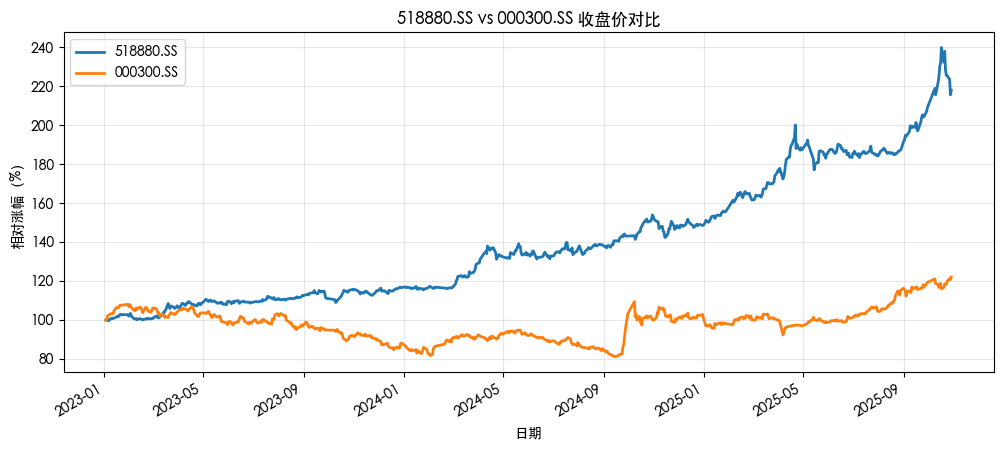

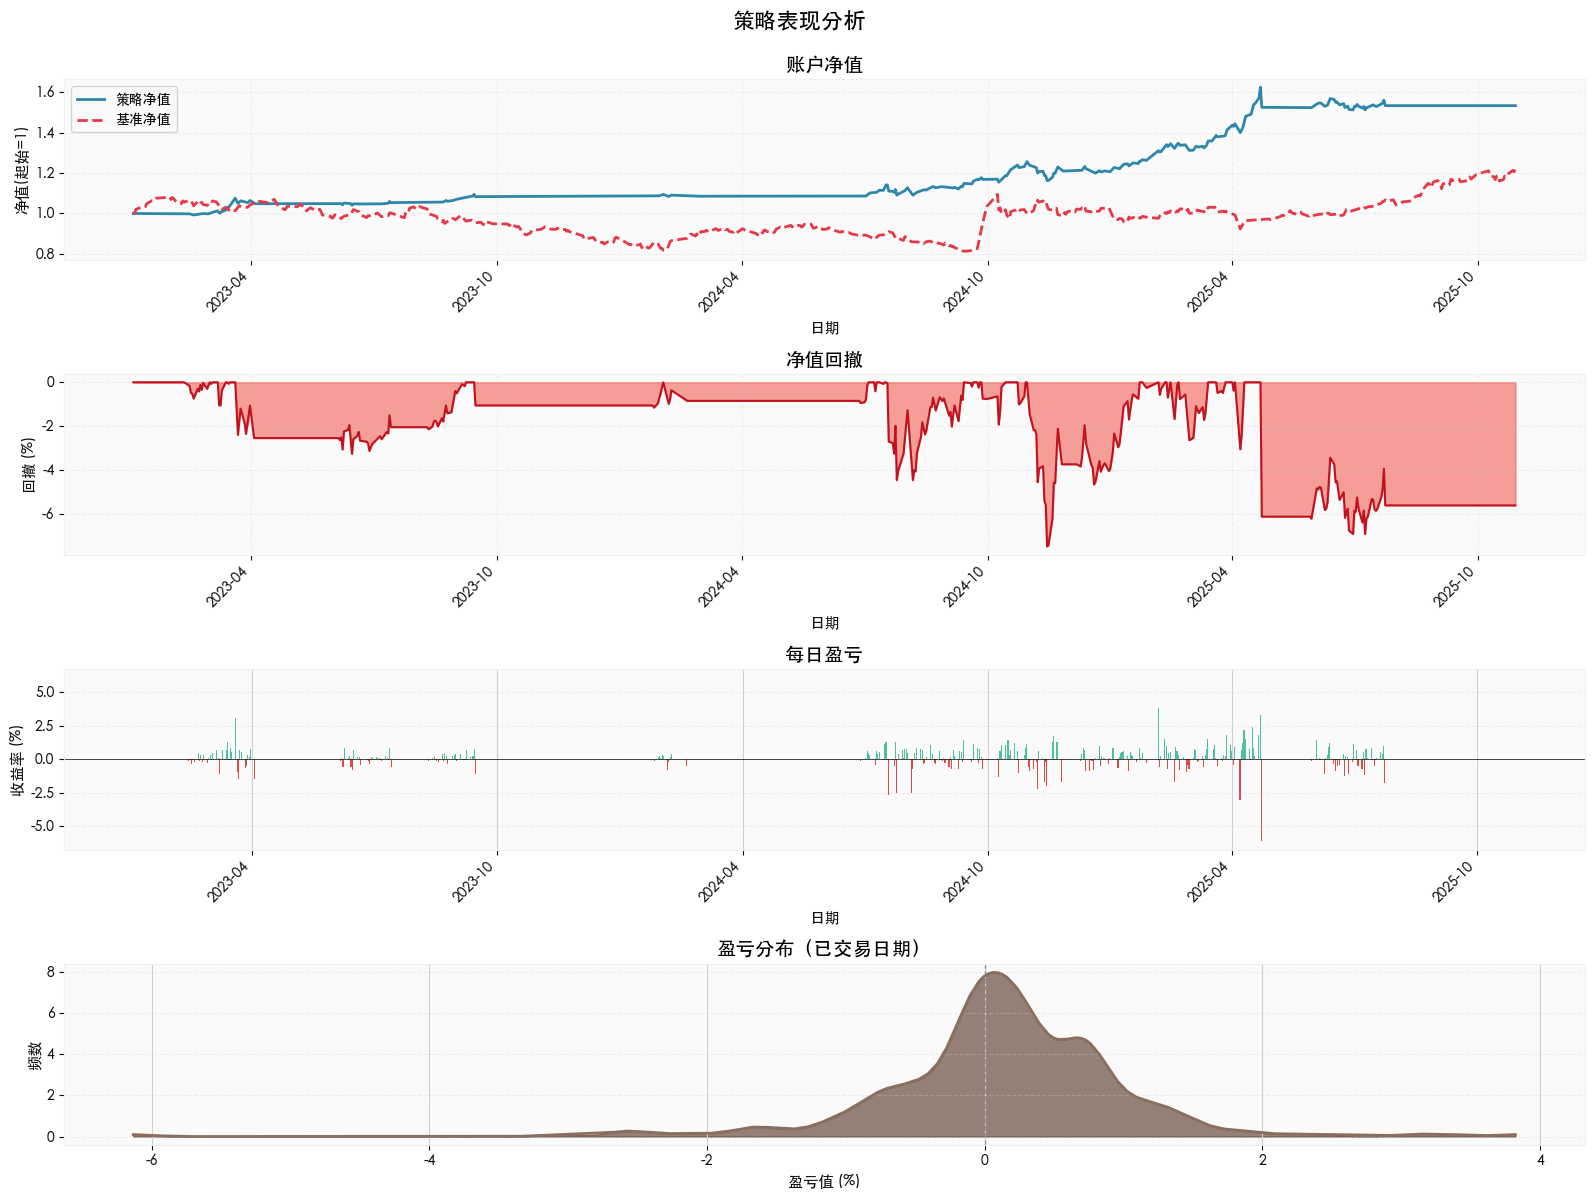

In [14]:
# 从0到1运行一遍策略，并得到回测分析结果

# 获取基础价格数据
data = fetcher_data(ticker,start_date,end_date)
benchmark_data = fetcher_data(benchmark_ticker,start_date,end_date)
plot_compare_benchmark(ticker,benchmark_ticker,data,benchmark_data)

# 构建特征因子，生成交易信号
indicators_data = calculate_boll(data,boll_period,boll_k)
signals_data = generate_signals(indicators_data)
plot_signals_boll(signals_data, save_fig=True)

# 计算评估指标，生成可视化报告
trades_data, values_data = run_strategy(ticker,signals_data,save_csv=True)
values_data, backtest_metrics = run_backtest_metrics(ticker,trades_data,values_data,save_csv=True)
run_backtest_charts(values_data, benchmark_data['Close'], save_fig=True)